In [1]:
# !pip install -r requirements.txt -qq

In [ ]:
# import sys
# sys.path.append('/home/rishabhtiwari/prm-inference')

: 

In [2]:
import torch
from transformers import AutoTokenizer

#from constants.model_constants import MODEL_CLASS_MAP
from skywork_o1_prm_inference.model_utils.prm_model import PRM_MODEL
from skywork_o1_prm_inference.model_utils.io_utils import prepare_input, derive_step_rewards

/home/eecs/hengyang/miniconda3/envs/reasoning/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def calculate_reward(model_path, problem, steps):
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    
    model = PRM_MODEL.from_pretrained(model_path, device_map="auto", torch_dtype=torch.float16)
    model = model.eval()
    input_ids, token_masks = prepare_input(
                            model_path, 
                            problem=problem, 
                            steps=steps, 
                            tokenizer=tokenizer
                        )
    with torch.inference_mode():
        logits = model(input_ids).logits

    rewards = derive_step_rewards(
        model_path, 
        logits, 
        token_masks, 
        tokenizer
    )
    return rewards

### Skywork/Skywork-o1-Open-PRM-Qwen-2.5-1.5B

In [4]:
SKYWORK_MODEL_PATH = "Skywork/Skywork-o1-Open-PRM-Qwen-2.5-1.5B" 
data = {
    # "problem": "Cindy's math and science books weigh 2 pounds each. Her French book weighs 4 pounds and her English book weighs 3 pounds. Her history book weighs twice as much as her English book. If Cindy carries all of her books at once, what will be the total weight of the books she is carrying?",
    "problem": "Find the sum of all integer bases $b>9$ for which $17_{b}$ is a divisor of $97_{b}$.",
    "steps": [
        "To determine the total weight of all Cindy's books, we need to calculate the weight of each book individually and then sum these weights.", 
        "First, for the math and science books:\n- Each math book weighs 2 pounds.\n- Each science book weighs 2 pounds.\n- Cindy has 2 math books and 2 science books.\n- Total weight of math books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Total weight of science books: \\(2 \\text{ books} \\times 2 \\text{ pounds/book} = 4 \\text{ pounds}\\).\n- Combined weight of math and science books: \\(4 \\text{ pounds} + 4 \\text{ pounds} = 8 \\text{ pounds}\\).", 
        "Second, for the French book:\n- The French book weighs 4 pounds.",
        "Third, for the English book:\n- The English book weighs 3 pounds.", 
        "Fourth, for the history book:\n- The history book weighs twice as much as the English book.\n- Weight of the history book: \\(2 \\times 3 \\text{ pounds} = 6 \\text{ pounds}\\).",
        "Finally, for the total weight:\n- Sum of the weights of all the books: \\[ 8 \\text{ pounds} \\text{ (math and science)} + 4 \\text{ pounds} \\text{ (French)} + 3 \\text{ pounds} \\text{ (English)} + 6 \\text{ pounds} \\text{ (history)} = 21 \\text{ pounds} \\]",
        "Therefore, the total weight of the books Cindy is carrying is \\(\\boxed{21}\\) pounds."
    ],
    # "answer": "17"
    "answer": "70"

}

: 

In [ ]:
# from transformers import AutoModelForCausalLM
# import torch

# model_path = "/home/rishabhtiwari/hf_cache/Skywork--Skywork-o1-Open-PRM-Qwen-2.5-1.5B"

# # Load the model
# print("Loading model...")
# model = MODEL_CLASS_MAP[SKYWORK_MODEL_PATH].from_pretrained(
#     model_path,
#     torch_dtype=torch.bfloat16,
#     device_map="cpu"  # Keep on CPU for conversion
# )

# # Save with safetensors format
# print("Saving in safetensors format...")
# model.save_pretrained(
#     model_path,
#     safe_serialization=True  # This enables safetensors format
# )

# print("Conversion complete!")

: 

In [5]:
tokenizer = AutoTokenizer.from_pretrained(SKYWORK_MODEL_PATH)
    
model = PRM_MODEL.from_pretrained(
    SKYWORK_MODEL_PATH, 
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=False 
).to("cuda:0")
print('done')
model = model.eval()
print(data["problem"])
input_ids, _, token_masks = prepare_input(
                        problem=data["problem"], 
                        response="\n\n".join(data["steps"]), 
                        tokenizer=tokenizer,
                        step_token="\n\n"
                    )

/rscratch/hengyang/prm-attack/skywork_o1_prm_inference/model_utils/modeling_base.py:264: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = loading_func(filename if 

done
Find the sum of all integer bases $b>9$ for which $17_{b}$ is a divisor of $97_{b}$.


In [6]:
in_ids = torch.tensor([input_ids], dtype=torch.int64).to("cuda:0")
attention_mask = torch.tensor([token_masks], dtype=torch.int64).to("cuda:0")

In [7]:
print(in_ids.shape)
print(attention_mask.shape)

torch.Size([1, 393])
torch.Size([1, 393])


In [8]:
with torch.inference_mode():
    logits = model(input_ids=in_ids, attention_mask=attention_mask)[-1]

rewards = derive_step_rewards(
    SKYWORK_MODEL_PATH, 
    logits, 
    token_masks, 
    tokenizer
)
print(rewards)
# Rewards should be close to: [[0.9304260015487671, 0.5120438933372498, 0.6100339889526367, 0.5191707015037537, 0.57666015625, 0.787788450717926, 0.8843944668769836]]

TypeError: derive_step_rewards() takes 2 positional arguments but 4 were given

In [ ]:
import torch.nn.functional as F

def optimize_tokens_for_max_reward(
    model, 
    tokenizer, 
    problem, 
    steps, 
    model_path, 
    device,
    num_new_tokens=10,
    num_iterations=100,
    learning_rate=0.1,
    temperature=1.0,
    entropy_weight_start=0.001,
    entropy_weight_end=0.1,
    entropy_schedule='linear'
):
    """
    Add random tokens at the end and optimize them to maximize reward.
    
    Args:
        model: The PRM model
        tokenizer: Tokenizer
        problem: Problem statement
        steps: List of reasoning steps
        model_path: Path to model for prepare_input
        device: Device to run on
        num_new_tokens: Number of tokens to add and optimize
        num_iterations: Number of optimization steps
        learning_rate: Learning rate for optimization
        temperature: Temperature for Gumbel-Softmax
        entropy_weight_start: Starting weight for entropy loss
        entropy_weight_end: Ending weight for entropy loss
        entropy_schedule: Schedule type ('linear', 'exponential', 'cosine')
    
    Returns:
        optimized_text: The optimized additional text
        reward_history: List of rewards during optimization
    """
    
    # Prepare the original input
    input_ids_orig, _, token_masks_orig = prepare_input(
        problem=problem, 
        response="\n\n".join(steps), 
        tokenizer=tokenizer,
        step_token="\n\n"
    )
    input_ids_orig = torch.tensor([input_ids_orig], dtype=torch.int64).to("cuda:0")
    token_masks_orig = torch.tensor([token_masks_orig], dtype=torch.int64).to("cuda:0")
    
    # Get the actual embedding layer to determine vocab size
    if hasattr(model, 'pretrained_model'):
        embed_layer = model.pretrained_model.get_input_embeddings()
    else:
        embed_layer = model.get_input_embeddings()
    
    # Use the actual vocab size from the embedding layer
    vocab_size = embed_layer.weight.shape[0]
    
    # Initialize random logits for new tokens (these will be optimized)
    # Shape: (num_new_tokens, vocab_size)
    new_token_logits = torch.randn(
        num_new_tokens, vocab_size, 
        device=device, 
        requires_grad=True
    )
    
    optimizer = torch.optim.Adam([new_token_logits], lr=learning_rate)
    
    reward_history = []
    discrete_reward_history = []
    entropy_history = []
    entropy_weight_history = []
    best_reward = -float('inf')
    best_discrete_reward = -float('inf')
    best_tokens = None
    
    print(f"Starting optimization...")
    print(f"Original sequence length: {len(input_ids_orig)}")
    print(f"Adding {num_new_tokens} optimizable tokens")
    print(f"Entropy weight schedule: {entropy_schedule}")
    print(f"  Start weight: {entropy_weight_start:.4f}")
    print(f"  End weight: {entropy_weight_end:.4f}")
    print()
    
    for iteration in range(num_iterations):
        optimizer.zero_grad()
        
        # Calculate scheduled entropy weight
        progress = iteration / max(num_iterations - 1, 1)  # 0 to 1
        if entropy_schedule == 'linear':
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * progress
        elif entropy_schedule == 'exponential':
            # Exponential growth from start to end
            entropy_weight = entropy_weight_start * (entropy_weight_end / entropy_weight_start) ** progress
        elif entropy_schedule == 'cosine':
            # Cosine annealing (smooth increase)
            entropy_weight = entropy_weight_start + (entropy_weight_end - entropy_weight_start) * (1 - np.cos(progress * np.pi)) / 2
        else:
            entropy_weight = entropy_weight_start  # Default to constant start weight
        
        entropy_weight_history.append(entropy_weight)
        
        # Use Gumbel-Softmax to get differentiable discrete sampling
        # This allows gradients to flow through the discrete token selection
        gumbel_softmax = F.gumbel_softmax(new_token_logits, tau=temperature, hard=False)
        
        # Calculate entropy of token distributions (measure of discreteness)
        # Lower entropy = more discrete/confident in token selection
        # Entropy = -sum(p * log(p))
        probs = F.softmax(new_token_logits, dim=-1)
        log_probs = F.log_softmax(new_token_logits, dim=-1)
        entropy_per_token = -(probs * log_probs).sum(dim=-1)  # Shape: (num_new_tokens,)
        avg_entropy = entropy_per_token.mean().item()
        entropy_history.append(avg_entropy)
        
        # Get embeddings for original tokens
        orig_embeddings = embed_layer(input_ids_orig)
        
        # Get embeddings for new tokens using weighted sum over vocabulary
        # Shape: (num_new_tokens, embedding_dim)
        # Cast gumbel_softmax to match embedding dtype
        gumbel_softmax = gumbel_softmax.to(embed_layer.weight.dtype)
        new_embeddings = torch.matmul(gumbel_softmax, embed_layer.weight)
        
        # Concatenate original and new embeddings
        full_embeddings = torch.cat([orig_embeddings, new_embeddings], dim=0)
        full_embeddings = full_embeddings.unsqueeze(0)  # Add batch dimension
        
        # Forward pass through model
        # The Skywork model returns (lm_logits, loss, value)
        with torch.set_grad_enabled(True):
            if hasattr(model, 'pretrained_model'):
                # For Skywork model, pass embeddings to the base model and get hidden states
                base_output = model.pretrained_model(
                    inputs_embeds=full_embeddings, 
                    output_hidden_states=True
                )
                last_hidden_state = base_output.hidden_states[-1]
                # Pass through value head to get reward logits
                reward_logits = model.v_head(last_hidden_state).squeeze(-1)
                # Get the reward for the last token
                reward_proxy = torch.sigmoid(reward_logits[0, -1])
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs = model(inputs_embeds=full_embeddings)
                logits = outputs[-1] if isinstance(outputs, tuple) else outputs.logits
                # For other models that output token logits
                reward_proxy = torch.sigmoid(logits[0, -1, :])
        
        # Loss: negative reward (we want to maximize reward)
        # Using scheduled entropy weight that increases with iterations
        loss = -reward_proxy + entropy_weight * entropy_per_token.mean()
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        
        # Track progress
        current_reward = reward_proxy.item()
        reward_history.append(current_reward)
        
        # Evaluate discrete token reward (without gradients)
        with torch.no_grad():
            # Get hard discrete tokens
            discrete_token_ids = torch.argmax(new_token_logits, dim=-1)
            
            # Get embeddings for discrete tokens
            discrete_embeddings = embed_layer(discrete_token_ids)
            
            # Concatenate with original embeddings
            full_discrete_embeddings = torch.cat([orig_embeddings, discrete_embeddings], dim=0)
            full_discrete_embeddings = full_discrete_embeddings.unsqueeze(0)
            
            # Forward pass with discrete tokens
            if hasattr(model, 'pretrained_model'):
                base_output_discrete = model.pretrained_model(
                    inputs_embeds=full_discrete_embeddings,
                    output_hidden_states=True
                )
                last_hidden_state_discrete = base_output_discrete.hidden_states[-1]
                reward_logits_discrete = model.v_head(last_hidden_state_discrete).squeeze(-1)
                discrete_reward = torch.sigmoid(reward_logits_discrete[0, -1]).item()
            else:
                raise NotImplementedError("Only Skywork model is supported for now")
                outputs_discrete = model(inputs_embeds=full_discrete_embeddings)
                logits_discrete = outputs_discrete[-1] if isinstance(outputs_discrete, tuple) else outputs_discrete.logits
                discrete_reward = torch.sigmoid(logits_discrete[0, -1, :]).item()
            
            discrete_reward_history.append(discrete_reward)
        
        if current_reward > best_reward:
            best_reward = current_reward
            # Get hard token ids for the best configuration
            
        
        if discrete_reward > best_discrete_reward:
            best_discrete_reward = discrete_reward
            best_token_ids = torch.argmax(new_token_logits, dim=-1)
            best_tokens = best_token_ids.detach().cpu().tolist()
        
        if (iteration + 1) % 10 == 0:
            # Decode current best tokens
            current_tokens = torch.argmax(gumbel_softmax, dim=-1).detach().cpu().tolist()
            decoded_text = tokenizer.decode(current_tokens)
            print(f"Iteration {iteration + 1}/{num_iterations}")
            print(f"  Soft Reward (Gumbel): {current_reward:.4f} | Best: {best_reward:.4f}")
            print(f"  Discrete Reward (Hard): {discrete_reward:.4f} | Best: {best_discrete_reward:.4f}")
            print(f"  Reward Gap (Soft-Hard): {current_reward - discrete_reward:+.4f}")
            print(f"  Entropy Weight: {entropy_weight:.6f}")
            print(f"  Avg Entropy: {avg_entropy:.4f} (max possible: {np.log(vocab_size):.4f})")
            print(f"  Current Tokens: {decoded_text[:100]}")
            print()
    
    # Decode the best tokens found
    optimized_text = tokenizer.decode(best_tokens)
    
    print(f"\nOptimization Complete!")
    print(f"\nReward Metrics:")
    print(f"  Best Soft Reward (Gumbel): {best_reward:.4f}")
    print(f"  Best Discrete Reward (Hard): {best_discrete_reward:.4f}")
    print(f"  Final Soft Reward: {reward_history[-1]:.4f}")
    print(f"  Final Discrete Reward: {discrete_reward_history[-1]:.4f}")
    print(f"  Final Reward Gap: {reward_history[-1] - discrete_reward_history[-1]:+.4f}")
    print(f"\nEntropy Metrics:")
    print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
    print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
    print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
    print(f"\nWeight Schedule:")
    print(f"  Final Entropy Weight: {entropy_weight_history[-1]:.6f}")
    print(f"  Initial Entropy Weight: {entropy_weight_history[0]:.6f}")
    print(f"\nOptimized Text: {optimized_text}")
    
    return optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, best_tokens


In [13]:
# Run the optimization
import numpy as np
optimized_text, reward_history, discrete_reward_history, entropy_history, entropy_weight_history, optimized_tokens = optimize_tokens_for_max_reward(
    model=model,
    tokenizer=tokenizer,
    problem=data["problem"],
    steps=data["steps"],
    model_path=SKYWORK_MODEL_PATH,
    device=torch.device("cuda:0"),
    num_new_tokens=10,  # Number of tokens to optimize
    num_iterations=200,  # Number of optimization steps
    learning_rate=0.5,   # Learning rate
    temperature=0.5,     # Temperature for Gumbel-Softmax (lower = more discrete)
    entropy_weight_start=0.001,  # Starting entropy weight
    entropy_weight_end=0.1,      # Ending entropy weight
    entropy_schedule='cosine'    # Schedule type: 'linear', 'exponential', or 'cosine'
)


Starting optimization...
Original sequence length: 393
Adding 10 optimizable tokens
Entropy weight schedule: cosine
  Start weight: 0.0010
  End weight: 0.1000



TypeError: embedding(): argument 'indices' (position 2) must be Tensor, not list

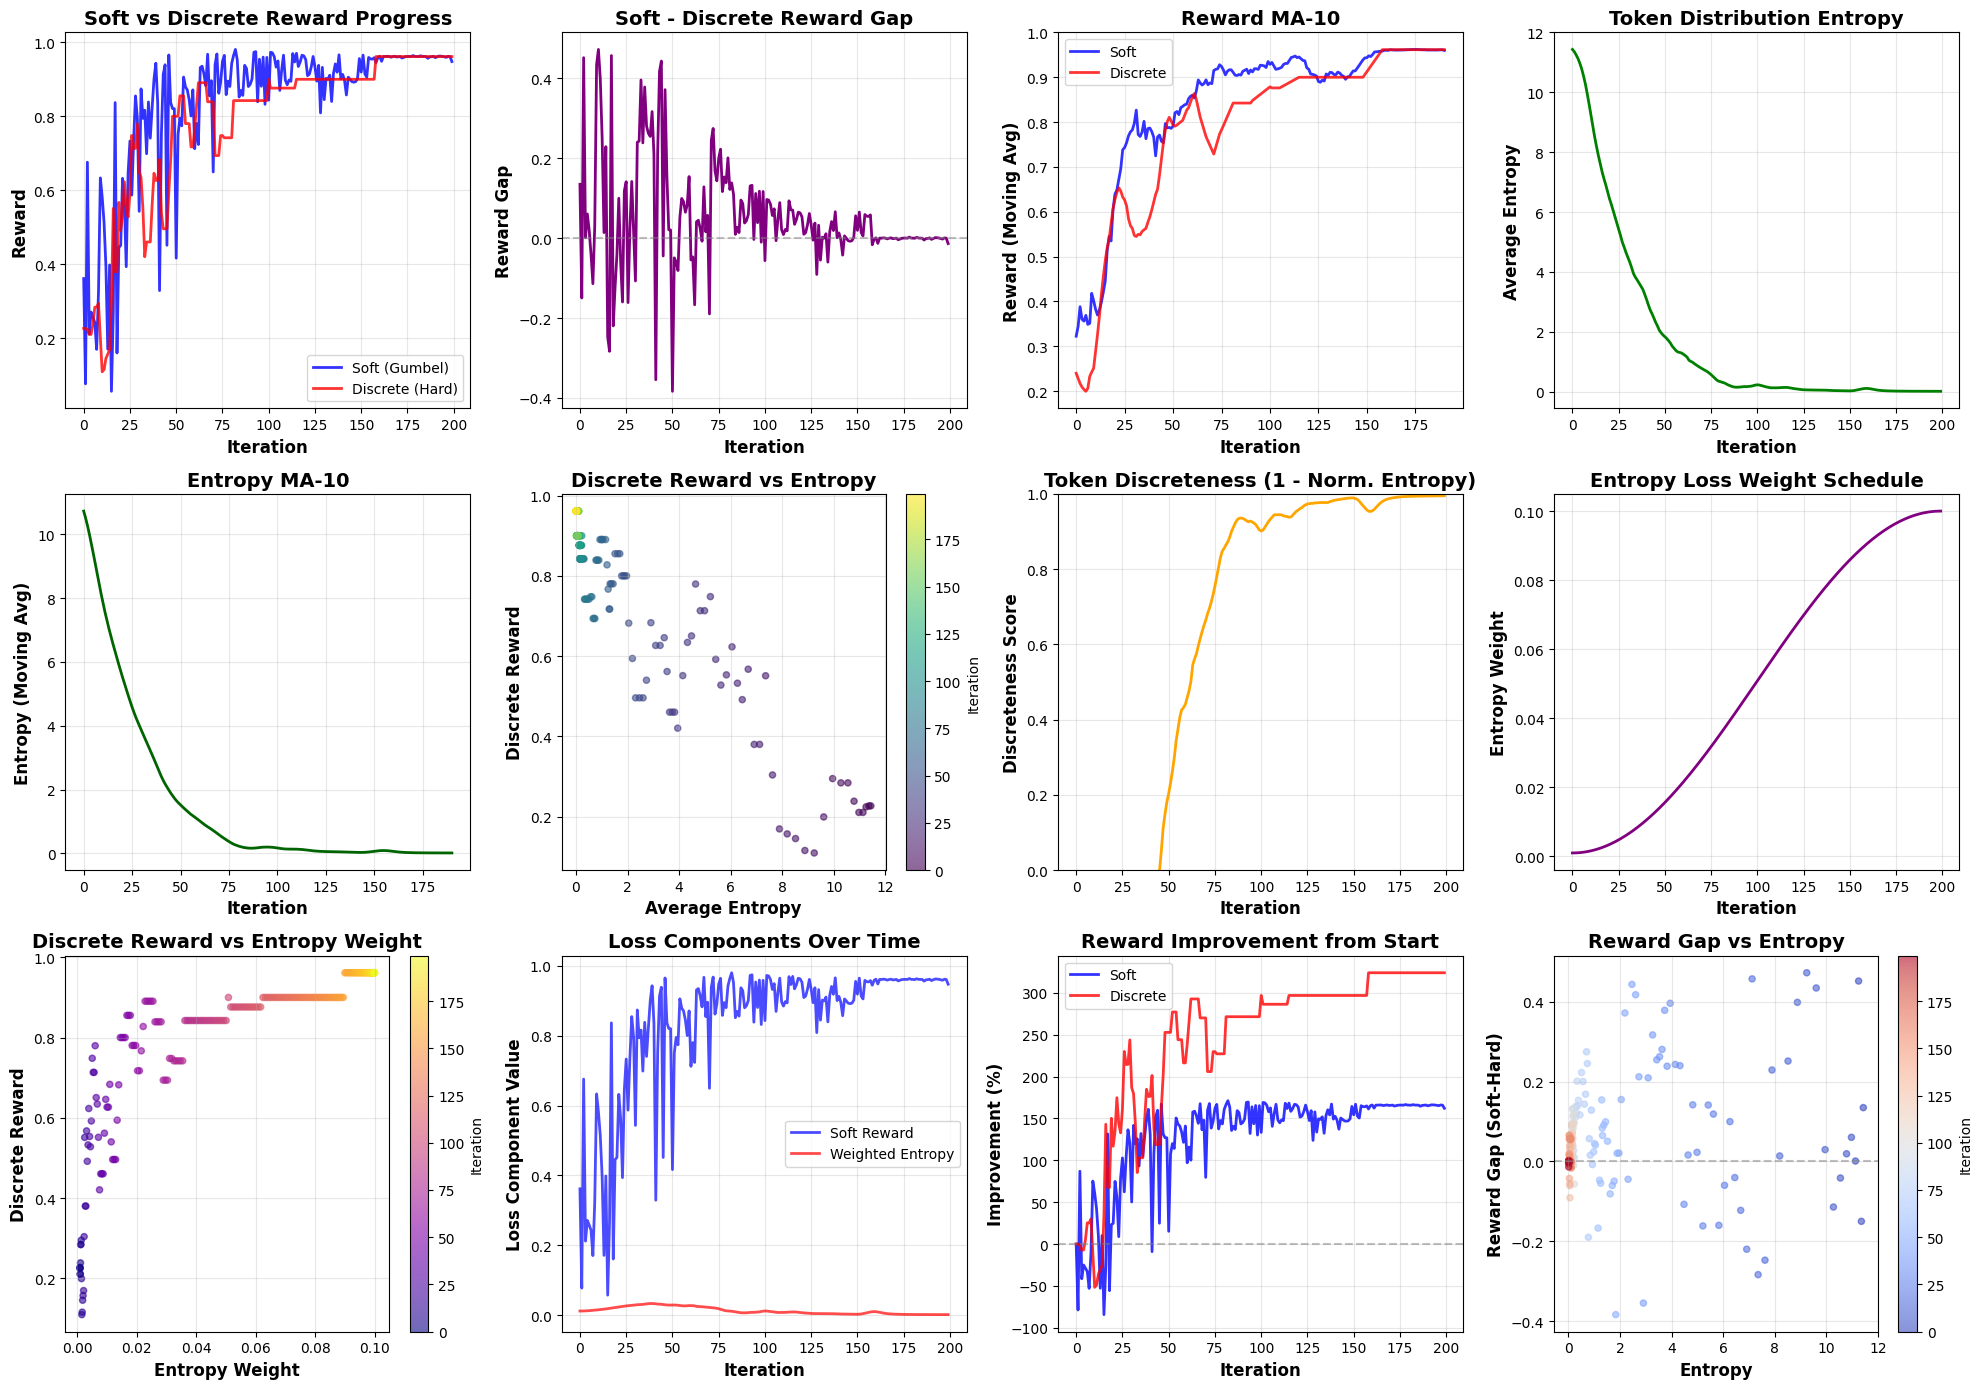


Optimization Summary:

Soft Reward Metrics (Gumbel-Softmax):
  Initial: 0.3615
  Final: 0.9477
  Best: 0.9806
  Improvement: 0.6190
  Improvement %: 171.23%

Discrete Reward Metrics (Hard Tokens):
  Initial: 0.2267
  Final: 0.9614
  Best: 0.9614
  Improvement: 0.7346
  Improvement %: 324.00%

Reward Gap Analysis (Soft - Discrete):
  Initial Gap: +0.1348
  Final Gap: -0.0136
  Average Gap: +0.0520
  Gap Change: -0.1484
  Max Gap: +0.4722 (iter 11)
  Min Gap: -0.3832 (iter 51)

Entropy Metrics:
  Initial Avg Entropy: 11.4313
  Final Avg Entropy: 0.0109
  Entropy Reduction: 11.4203
  Max Possible Entropy: 2.3026
  Final Discreteness: 99.53%

Entropy Weight Schedule:
  Initial Weight: 0.001000
  Final Weight: 0.100000
  Weight Increase: 0.099000
  Weight Multiplier: 100.00x

Loss Component Analysis:
  Initial Weighted Entropy: 0.011431
  Final Weighted Entropy: 0.001091
  Despite 100.0x weight increase, entropy decreased by 99.9%


In [155]:
# Plot the optimization progress
plt.figure(figsize=(20, 14))

# Plot 1: Soft vs Discrete Reward Comparison
plt.subplot(3, 4, 1)
plt.plot(reward_history, linewidth=2, color='blue', label='Soft (Gumbel)', alpha=0.8)
plt.plot(discrete_reward_history, linewidth=2, color='red', label='Discrete (Hard)', alpha=0.8)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward', fontsize=12, fontweight='bold')
plt.title('Soft vs Discrete Reward Progress', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 2: Reward Gap (Soft - Discrete)
plt.subplot(3, 4, 2)
reward_gap = np.array(reward_history) - np.array(discrete_reward_history)
plt.plot(reward_gap, linewidth=2, color='purple')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap', fontsize=12, fontweight='bold')
plt.title('Soft - Discrete Reward Gap', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 3: Reward moving average 
plt.subplot(3, 4, 3)
window_size = 10
if len(reward_history) >= window_size:
    soft_ma = np.convolve(reward_history, np.ones(window_size)/window_size, mode='valid')
    discrete_ma = np.convolve(discrete_reward_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(soft_ma, linewidth=2, color='blue', label='Soft', alpha=0.8)
    plt.plot(discrete_ma, linewidth=2, color='red', label='Discrete', alpha=0.8)
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Reward (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Reward MA-{window_size}', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)

# Plot 4: Entropy progress
plt.subplot(3, 4, 4)
plt.plot(entropy_history, linewidth=2, color='green')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Average Entropy', fontsize=12, fontweight='bold')
plt.title('Token Distribution Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 5: Entropy moving average
plt.subplot(3, 4, 5)
if len(entropy_history) >= window_size:
    entropy_ma = np.convolve(entropy_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(entropy_ma, linewidth=2, color='darkgreen')
    plt.xlabel('Iteration', fontsize=12, fontweight='bold')
    plt.ylabel('Entropy (Moving Avg)', fontsize=12, fontweight='bold')
    plt.title(f'Entropy MA-{window_size}', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)

# Plot 6: Discrete Reward vs Entropy scatter
plt.subplot(3, 4, 6)
scatter = plt.scatter(entropy_history, discrete_reward_history, c=range(len(discrete_reward_history)), 
                     cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, label='Iteration')
plt.xlabel('Average Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 7: Discreteness metric (inverse of normalized entropy)
plt.subplot(3, 4, 7)
# Normalize entropy by max possible (uniform distribution)
max_entropy = np.log(len(optimized_tokens))  # For discrete uniform distribution
normalized_entropy = np.array(entropy_history) / max_entropy
discreteness = 1 - normalized_entropy  # Higher = more discrete
plt.plot(discreteness, linewidth=2, color='orange')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Discreteness Score', fontsize=12, fontweight='bold')
plt.title('Token Discreteness (1 - Norm. Entropy)', fontsize=14, fontweight='bold')
plt.ylim([0, 1])
plt.grid(alpha=0.3)

# Plot 8: Entropy Weight Schedule
plt.subplot(3, 4, 8)
plt.plot(entropy_weight_history, linewidth=2, color='purple')
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.title('Entropy Loss Weight Schedule', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 9: Entropy Weight vs Discrete Reward
plt.subplot(3, 4, 9)
scatter2 = plt.scatter(entropy_weight_history, discrete_reward_history, c=range(len(discrete_reward_history)),
                      cmap='plasma', alpha=0.6, s=20)
plt.colorbar(scatter2, label='Iteration')
plt.xlabel('Entropy Weight', fontsize=12, fontweight='bold')
plt.ylabel('Discrete Reward', fontsize=12, fontweight='bold')
plt.title('Discrete Reward vs Entropy Weight', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# Plot 10: Effective Loss Components Over Time
plt.subplot(3, 4, 10)
reward_component = np.array(reward_history)
entropy_component = np.array(entropy_history) * np.array(entropy_weight_history)
plt.plot(reward_component, linewidth=2, color='blue', label='Soft Reward', alpha=0.7)
plt.plot(entropy_component, linewidth=2, color='red', label='Weighted Entropy', alpha=0.7)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Loss Component Value', fontsize=12, fontweight='bold')
plt.title('Loss Components Over Time', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 11: Reward Improvement (relative to initial)
plt.subplot(3, 4, 11)
soft_improvement = (np.array(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100
discrete_improvement = (np.array(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100
plt.plot(soft_improvement, linewidth=2, color='blue', label='Soft', alpha=0.8)
plt.plot(discrete_improvement, linewidth=2, color='red', label='Discrete', alpha=0.8)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Iteration', fontsize=12, fontweight='bold')
plt.ylabel('Improvement (%)', fontsize=12, fontweight='bold')
plt.title('Reward Improvement from Start', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot 12: Correlation: Reward Gap vs Entropy
plt.subplot(3, 4, 12)
plt.scatter(entropy_history, reward_gap, c=range(len(reward_gap)), cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(label='Iteration')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Entropy', fontsize=12, fontweight='bold')
plt.ylabel('Reward Gap (Soft-Hard)', fontsize=12, fontweight='bold')
plt.title('Reward Gap vs Entropy', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nOptimization Summary:")
print(f"=" * 70)
print(f"\nSoft Reward Metrics (Gumbel-Softmax):")
print(f"  Initial: {reward_history[0]:.4f}")
print(f"  Final: {reward_history[-1]:.4f}")
print(f"  Best: {max(reward_history):.4f}")
print(f"  Improvement: {max(reward_history) - reward_history[0]:.4f}")
print(f"  Improvement %: {(max(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nDiscrete Reward Metrics (Hard Tokens):")
print(f"  Initial: {discrete_reward_history[0]:.4f}")
print(f"  Final: {discrete_reward_history[-1]:.4f}")
print(f"  Best: {max(discrete_reward_history):.4f}")
print(f"  Improvement: {max(discrete_reward_history) - discrete_reward_history[0]:.4f}")
print(f"  Improvement %: {(max(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100:.2f}%")

print(f"\nReward Gap Analysis (Soft - Discrete):")
initial_gap = reward_history[0] - discrete_reward_history[0]
final_gap = reward_history[-1] - discrete_reward_history[-1]
avg_gap = np.mean(reward_gap)
print(f"  Initial Gap: {initial_gap:+.4f}")
print(f"  Final Gap: {final_gap:+.4f}")
print(f"  Average Gap: {avg_gap:+.4f}")
print(f"  Gap Change: {final_gap - initial_gap:+.4f}")
print(f"  Max Gap: {max(reward_gap):+.4f} (iter {np.argmax(reward_gap)+1})")
print(f"  Min Gap: {min(reward_gap):+.4f} (iter {np.argmin(reward_gap)+1})")

print(f"\nEntropy Metrics:")
print(f"  Initial Avg Entropy: {entropy_history[0]:.4f}")
print(f"  Final Avg Entropy: {entropy_history[-1]:.4f}")
print(f"  Entropy Reduction: {entropy_history[0] - entropy_history[-1]:.4f}")
print(f"  Max Possible Entropy: {np.log(len(optimized_tokens)):.4f}")
print(f"  Final Discreteness: {(1 - entropy_history[-1]/np.log(len(optimized_tokens)))*100:.2f}%")

print(f"\nEntropy Weight Schedule:")
print(f"  Initial Weight: {entropy_weight_history[0]:.6f}")
print(f"  Final Weight: {entropy_weight_history[-1]:.6f}")
print(f"  Weight Increase: {entropy_weight_history[-1] - entropy_weight_history[0]:.6f}")
print(f"  Weight Multiplier: {entropy_weight_history[-1] / max(entropy_weight_history[0], 1e-9):.2f}x")

print(f"\nLoss Component Analysis:")
print(f"  Initial Weighted Entropy: {entropy_history[0] * entropy_weight_history[0]:.6f}")
print(f"  Final Weighted Entropy: {entropy_history[-1] * entropy_weight_history[-1]:.6f}")
print(f"  Despite {entropy_weight_history[-1]/entropy_weight_history[0]:.1f}x weight increase, entropy decreased by {(1-entropy_history[-1]/entropy_history[0])*100:.1f}%")


In [137]:
# Additional analysis on discrete vs soft rewards
print(f"\n{'=' * 70}")
print(f"DISCRETE vs SOFT REWARD ANALYSIS")
print(f"{'=' * 70}")

print(f"\nKey Metrics:")
soft_improvement = (max(reward_history) - reward_history[0]) / max(abs(reward_history[0]), 1e-6) * 100
discrete_improvement = (max(discrete_reward_history) - discrete_reward_history[0]) / max(abs(discrete_reward_history[0]), 1e-6) * 100

print(f"  Soft (Gumbel) Reward Improvement: {soft_improvement:.1f}%")
print(f"  Discrete (Hard) Reward Improvement: {discrete_improvement:.1f}%")

print(f"\nReward Gap Statistics:")
reward_gap = np.array(reward_history) - np.array(discrete_reward_history)
print(f"  Mean Gap: {np.mean(reward_gap):.4f}")
print(f"  Std Gap: {np.std(reward_gap):.4f}")
print(f"  Gap Correlation with Entropy: {np.corrcoef(entropy_history, reward_gap)[0,1]:.4f}")

print(f"\nOptimization Effectiveness:")
if discrete_improvement > 0:
    print(f"  ✓ Discrete rewards ARE improving ({discrete_improvement:.1f}%)")
    print(f"  ✓ Optimization successfully transfers to discrete tokens!")
    if discrete_improvement > 0.5 * soft_improvement:
        print(f"  ✓ Strong transfer: {discrete_improvement/soft_improvement*100:.1f}% of soft improvement")
    else:
        print(f"  ⚠ Moderate transfer: {discrete_improvement/soft_improvement*100:.1f}% of soft improvement")
else:
    print(f"  ⚠ Discrete rewards NOT improving")
    print(f"  ⚠ May be exploiting soft approximation without real discrete gains")

print(f"\nEntropy Schedule Effectiveness:")
entropy_reduction_pct = (1 - entropy_history[-1]/entropy_history[0]) * 100
print(f"  Entropy reduced by {entropy_reduction_pct:.1f}% despite {entropy_weight_history[-1]/entropy_weight_history[0]:.1f}x weight increase")
print(f"  This indicates tokens are becoming more discrete (good for discrete reward)")

print(f"{'=' * 70}")



DISCRETE vs SOFT REWARD ANALYSIS

Key Metrics:
  Soft (Gumbel) Reward Improvement: 148.4%
  Discrete (Hard) Reward Improvement: 316.9%

Reward Gap Statistics:
  Mean Gap: 0.0473
  Std Gap: 0.1505
  Gap Correlation with Entropy: 0.0761

Optimization Effectiveness:
  ✓ Discrete rewards ARE improving (316.9%)
  ✓ Optimization successfully transfers to discrete tokens!
  ✓ Strong transfer: 213.5% of soft improvement

Entropy Schedule Effectiveness:
  Entropy reduced by 99.9% despite 100.0x weight increase
  This indicates tokens are becoming more discrete (good for discrete reward)


In [162]:
min_reward_steps[-1]

'Since none of the negative divisors of 56 yield a valid \\( b \\) such that \\( b > 9 \\), there are no integer bases \\( b > 9 \\) for which \\( 17_b \\) is a divisor of \\( 97_b \\). Therefore, the sum of all such integer bases is:\n\\[\n\\boxed{0}\n\\]'

In [161]:
optimized_text

'"}\n\n Sor tenemos nämlich DaCOOKIE\ttr godt reckless primera'

In [160]:
tokenizer.encode(min_reward_steps.copy()[-1] +optimized_text)

[12549,
 6857,
 315,
 279,
 8225,
 3429,
 41214,
 315,
 220,
 20,
 21,
 7540,
 264,
 2697,
 17767,
 293,
 1124,
 8,
 1741,
 429,
 17767,
 293,
 861,
 220,
 24,
 1124,
 701,
 1052,
 525,
 902,
 7546,
 23092,
 17767,
 293,
 861,
 220,
 24,
 1124,
 8,
 369,
 892,
 17767,
 220,
 16,
 22,
 880,
 1124,
 8,
 374,
 264,
 49109,
 315,
 17767,
 220,
 24,
 22,
 880,
 1124,
 568,
 15277,
 11,
 279,
 2629,
 315,
 678,
 1741,
 7546,
 23092,
 374,
 510,
 59,
 9640,
 59,
 79075,
 90,
 15,
 532,
 59,
 19177,
 630,
 29531,
 70448,
 143525,
 14235,
 44796,
 25583,
 80223,
 53217,
 43669]

In [157]:
optimized_steps = min_reward_steps.copy()
optimized_steps[-1] = optimized_steps[-1] +optimized_text
input_ids_orig, token_masks_orig = prepare_input(
        SKYWORK_MODEL_PATH, 
        problem=data["problem"], 
        steps=optimized_steps, 
        tokenizer=tokenizer,
        device=torch.device("cuda:0")
    )
# input_ids_orig = torch.cat([input_ids_orig,torch.tensor(optimized_tokens,device=torch.device("cuda:0"))],dim=0)
embed_layer = model.pretrained_model.get_input_embeddings()
orig_embeddings = embed_layer(input_ids_orig).unsqueeze(0)
base_output = model.pretrained_model(
                    inputs_embeds=orig_embeddings, 
                    output_hidden_states=True
                )
last_hidden_state = base_output.hidden_states[-1]
# Pass through value head to get reward logits
reward_logits = model.v_head(last_hidden_state).squeeze(-1)
# Get the reward for the last token
reward_proxy = torch.sigmoid(reward_logits[0, -1])
print(reward_proxy)

tensor(0.0877, device='cuda:0', grad_fn=<SigmoidBackward0>)


In [153]:
tokenizer.decode(input_ids_orig[-10:])

'[\n\\boxed{0}\n\\]吉林省\n'

In [117]:
torch.cat([input_ids_orig,torch.tensor(tokenizer.encode(optimized_text),device=torch.device("cuda:0"))],dim=0)

tensor([151644,   9885,    279,  ...,  73638, 143578,  44503], device='cuda:0')

In [118]:
token_masks_orig.sum()

tensor(10, device='cuda:0')

In [119]:
reward_logits.shape

torch.Size([1, 1232])

In [122]:
torch.sigmoid(reward_logits).squeeze()

tensor([0.3489, 0.4598, 0.2812,  ..., 0.1817, 0.5119, 0.3981], device='cuda:0',
       grad_fn=<SqueezeBackward0>)

In [65]:
orig_embeddings.shape

torch.Size([1, 781, 1536])

In [148]:
tokenizer.encode(optimized_text)

[110904]

In [146]:
# Now evaluate the optimized trajectory with the actual PRM reward function
# Create a new step by appending the optimized text to the last step
optimized_steps = min_reward_steps.copy()
optimized_steps[-1] = optimized_steps[-1] + optimized_text

# optimized_steps.append(optimized_text)

print(f"Original trajectory steps: {len(min_reward_steps)}")
print(f"Optimized trajectory steps: {len(optimized_steps)}")
print(f"\nNew optimized step:")
print(f"  {optimized_text}")
print()

# Calculate rewards for the optimized trajectory
optimized_rewards = calculate_stepwise_rewards_for_trajectory(
    model=model,
    tokenizer=tokenizer,
    problem=data["problem"],
    steps=optimized_steps,
    model_path=SKYWORK_MODEL_PATH,
    device=torch.device("cuda:0")
)

optimized_avg_reward = np.mean(optimized_rewards) if optimized_rewards else 0

print(f"\nReward Comparison:")
print(f"  Original Average Reward: {min_reward_value:.4f}")
print(f"  Original Step Rewards: {[f'{r:.4f}' for r in all_trajectory_rewards[min_reward_idx]]}")
print()
print(f"  Optimized Average Reward: {optimized_avg_reward:.4f}")
print(f"  Optimized Step Rewards: {[f'{r:.4f}' for r in optimized_rewards]}")
print()
print(f"  Improvement: {optimized_avg_reward - min_reward_value:.4f}")
print(f"  Improvement %: {(optimized_avg_reward - min_reward_value) / max(abs(min_reward_value), 1e-6) * 100:.2f}%")


Original trajectory steps: 10
Optimized trajectory steps: 10

New optimized step:
  吉林省


Reward Comparison:
  Original Average Reward: 0.2897
  Original Step Rewards: ['0.4929', '0.4244', '0.3741', '0.3600', '0.3226', '0.2696', '0.2344', '0.1931', '0.1471', '0.0785']

  Optimized Average Reward: 0.2915
  Optimized Step Rewards: ['0.4929', '0.4244', '0.3741', '0.3600', '0.3226', '0.2696', '0.2344', '0.1931', '0.1471', '0.0972']

  Improvement: 0.0019
  Improvement %: 0.64%


In [33]:
# Analyze correlation between average rewards and correctness
print("Trajectory Analysis: Rewards vs Correctness")
print("=" * 70)

for i in range(len(generated_answers)):
    avg_reward = trajectory_avg_rewards[i]
    is_correct = correctness[i]
    predicted_ans = predicted_answers[i]
    num_steps = len(parsed_generations[i])
    
    print(f"\nGeneration {i+1}:")
    print(f"  Predicted Answer: {predicted_ans}")
    print(f"  Correct: {'✓' if is_correct else '✗'}")
    print(f"  Number of Steps: {num_steps}")
    if avg_reward is not None:
        print(f"  Average Reward: {avg_reward:.4f}")
        if all_trajectory_rewards[i]:
            print(f"  Min Step Reward: {min(all_trajectory_rewards[i]):.4f}")
            print(f"  Max Step Reward: {max(all_trajectory_rewards[i]):.4f}")
    else:
        print(f"  Average Reward: N/A")

# Separate correct and incorrect trajectories
correct_rewards = [trajectory_avg_rewards[i] for i in range(len(correctness)) 
                   if correctness[i] == 1 and trajectory_avg_rewards[i] is not None]
incorrect_rewards = [trajectory_avg_rewards[i] for i in range(len(correctness)) 
                     if correctness[i] == 0 and trajectory_avg_rewards[i] is not None]

print("\n" + "=" * 70)
print("Comparison: Correct vs Incorrect Trajectories")
print("-" * 70)

if correct_rewards:
    print(f"Correct Trajectories (n={len(correct_rewards)}):")
    print(f"  Mean Average Reward: {np.mean(correct_rewards):.4f}")
    print(f"  Std Average Reward: {np.std(correct_rewards):.4f}")
else:
    print("Correct Trajectories: None")

if incorrect_rewards:
    print(f"\nIncorrect Trajectories (n={len(incorrect_rewards)}):")
    print(f"  Mean Average Reward: {np.mean(incorrect_rewards):.4f}")
    print(f"  Std Average Reward: {np.std(incorrect_rewards):.4f}")
else:
    print("\nIncorrect Trajectories: None")


Trajectory Analysis: Rewards vs Correctness

Generation 1:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.6563
  Min Step Reward: 0.4501
  Max Step Reward: 0.9278

Generation 2:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.6722
  Min Step Reward: 0.4396
  Max Step Reward: 0.9448

Generation 3:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.5684
  Min Step Reward: 0.3855
  Max Step Reward: 0.9224

Generation 4:
  Predicted Answer: 17
  Correct: ✗
  Number of Steps: 7
  Average Reward: 0.5249
  Min Step Reward: 0.2051
  Max Step Reward: 0.9528

Generation 5:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.5385
  Min Step Reward: 0.3343
  Max Step Reward: 0.9314

Generation 6:
  Predicted Answer: 21
  Correct: ✓
  Number of Steps: 7
  Average Reward: 0.6730
  Min Step Reward: 0.4924
  Max Step Reward: 0.9327

Generation 7:
  Predicted Answer: 21
  Correct: ✓
  Number of